In [43]:
from os.path import curdir
import pandas as pd

In [44]:
customers = pd.read_csv("./data/addresses.csv")


In [45]:
print (customers.head())

   company_id                                            address  total_spend
0           1  APARTMENT 2,\n52 BEDFORD ROAD,\nLONDON,\nENGLA...         5700
1           2           107 SHERINGHAM AVENUE,\nLONDON,\nN14 4UJ         4700
2           3  43 SUNNINGDALE,\nYATE,\nBRISTOL,\nENGLAND,\nBS...         5900
3           4  HAWESWATER HOUSE,\nLINGLEY MERE BUSINESS PARK,...         7200
4           5  AMBERFIELD BARN HOUSE AMBER LANE,\nCHART SUTTO...         4600


In [46]:
print (customers.shape)

(100000, 3)


In [47]:
customers.isnull().sum()

company_id       0
address        968
total_spend      0
dtype: int64

In [48]:
customers = customers.dropna(subset=['address'])

In [49]:
customers['total_spend'].describe()

count    99032.000000
mean      4951.673197
std       1500.642398
min          0.000000
25%       3900.000000
50%       5000.000000
75%       6000.000000
max      11700.000000
Name: total_spend, dtype: float64

In [8]:
len(customers)

99032

In [9]:
for i in customers["address"].head():
 print (i, "\n")

APARTMENT 2,
52 BEDFORD ROAD,
LONDON,
ENGLAND,
SW4 7HJ 

107 SHERINGHAM AVENUE,
LONDON,
N14 4UJ 

43 SUNNINGDALE,
YATE,
BRISTOL,
ENGLAND,
BS37 4HZ 

HAWESWATER HOUSE,
LINGLEY MERE BUSINESS PARK,
LINGLEY GREEN AVENUE,
GREAT SANKEY, WARRINGTON,
WA5 3LP 

AMBERFIELD BARN HOUSE AMBER LANE,
CHART SUTTON,
MAIDSTONE,
ENGLAND,
ME17 3SF 



In [10]:
customers['clean_add'] = customers['address'].str.upper()

In [11]:
customers.head()

,company_id,address,total_spend,clean_add
0,1,"APARTMENT 2,\n52 BEDFORD ROAD,\nLONDON,\nENGLA...",5700,"APARTMENT 2,\n52 BEDFORD ROAD,\nLONDON,\nENGLA..."
1,2,"107 SHERINGHAM AVENUE,\nLONDON,\nN14 4UJ",4700,"107 SHERINGHAM AVENUE,\nLONDON,\nN14 4UJ"
2,3,"43 SUNNINGDALE,\nYATE,\nBRISTOL,\nENGLAND,\nBS...",5900,"43 SUNNINGDALE,\nYATE,\nBRISTOL,\nENGLAND,\nBS..."
3,4,"HAWESWATER HOUSE,\nLINGLEY MERE BUSINESS PARK,...",7200,"HAWESWATER HOUSE,\nLINGLEY MERE BUSINESS PARK,..."
4,5,"AMBERFIELD BARN HOUSE AMBER LANE,\nCHART SUTTO...",4600,"AMBERFIELD BARN HOUSE AMBER LANE,\nCHART SUTTO..."


In [12]:
customers["clean_add"].str.contains("LONDON").sum()

np.int64(21768)

In [13]:
customers.head()
customers["clean_add"].str.contains("LONDON,").sum()

np.int64(20831)

In [14]:
customers["add_line"] = (
customers["clean_add"]
.str.split(",\n")
.apply(len)
)
customers["add_line"].value_counts().sort_index()

add_line
1        6
2       52
3     3284
4    35850
5    45931
6    13909
Name: count, dtype: int64

In [15]:
print(customers.loc[customers["add_line"] == 1, "clean_add"])

17789                      FALKIRK
31897                   HADDINGTON
61750          CREAG BHAITHEACHAIN
75330                     NEWMILNS
78045    REDCLOAK FARM, STONEHAVEN
90897     REFER TO PARENT REGISTRY
Name: clean_add, dtype: str


In [16]:
print(customers.head())

   company_id                                            address  total_spend  \
0           1  APARTMENT 2,\n52 BEDFORD ROAD,\nLONDON,\nENGLA...         5700   
1           2           107 SHERINGHAM AVENUE,\nLONDON,\nN14 4UJ         4700   
2           3  43 SUNNINGDALE,\nYATE,\nBRISTOL,\nENGLAND,\nBS...         5900   
3           4  HAWESWATER HOUSE,\nLINGLEY MERE BUSINESS PARK,...         7200   
4           5  AMBERFIELD BARN HOUSE AMBER LANE,\nCHART SUTTO...         4600   

                                           clean_add  add_line  
0  APARTMENT 2,\n52 BEDFORD ROAD,\nLONDON,\nENGLA...         5  
1           107 SHERINGHAM AVENUE,\nLONDON,\nN14 4UJ         3  
2  43 SUNNINGDALE,\nYATE,\nBRISTOL,\nENGLAND,\nBS...         5  
3  HAWESWATER HOUSE,\nLINGLEY MERE BUSINESS PARK,...         5  
4  AMBERFIELD BARN HOUSE AMBER LANE,\nCHART SUTTO...         5  


In [17]:
print((
customers[customers["add_line"] == 2]
.sample(5)["clean_add"]))

56604                       103 NEWGATE STREET,\nLONDON
89842    BRANCH REGISTRATION,\nREFER TO PARENT REGISTRY
26069                              MONYMUSK,\nINVERVRIE
8799                       27 ALBEMARLE STREET,\nLONDON
71272                   16 CHARLOTTE SQUARE,\nEDINBURGH
Name: clean_add, dtype: str


In [ ]:
# Start working on the "cities" table

In [18]:
cities = pd.read_csv("./data/cities.csv", header=None, names=["city"])

In [19]:
print (cities.head())

              city
0          England
1             Bath
2      Birmingham*
3        Bradford*
4  Brighton & Hove


In [ ]:
# Remove the name of four countries and * from the cities list

In [20]:
countries_to_remove = ["England", "Scotland", "Wales", "Northern Ireland"]

In [21]:
cities = cities[~cities["city"].isin(countries_to_remove)]

In [22]:
cities["city"] = cities["city"].str.replace("*", "", regex=False)

In [23]:
cities["city"] = cities["city"].str.upper()

In [24]:
print(cities.head())

              city
1             BATH
2       BIRMINGHAM
3         BRADFORD
4  BRIGHTON & HOVE
5          BRISTOL


In [ ]:
# For each city in the cities table, look inside every customer address. If the address contains that city name as a separate address line, write that city name into the customer’s city column.

In [25]:
for j in cities["city"]:
    pattern = "\n" + j + ","
    matched = customers["clean_add"].str.contains(pattern, na=False)
    customers.loc[matched, "city"] = j

In [26]:
customers["city"] = customers["city"].fillna("OTHER")

In [27]:
customers.head()

,company_id,address,total_spend,clean_add,add_line,city
0,1,"APARTMENT 2,\n52 BEDFORD ROAD,\nLONDON,\nENGLA...",5700,"APARTMENT 2,\n52 BEDFORD ROAD,\nLONDON,\nENGLA...",5,LONDON
1,2,"107 SHERINGHAM AVENUE,\nLONDON,\nN14 4UJ",4700,"107 SHERINGHAM AVENUE,\nLONDON,\nN14 4UJ",3,LONDON
2,3,"43 SUNNINGDALE,\nYATE,\nBRISTOL,\nENGLAND,\nBS...",5900,"43 SUNNINGDALE,\nYATE,\nBRISTOL,\nENGLAND,\nBS...",5,BRISTOL
3,4,"HAWESWATER HOUSE,\nLINGLEY MERE BUSINESS PARK,...",7200,"HAWESWATER HOUSE,\nLINGLEY MERE BUSINESS PARK,...",5,OTHER
4,5,"AMBERFIELD BARN HOUSE AMBER LANE,\nCHART SUTTO...",4600,"AMBERFIELD BARN HOUSE AMBER LANE,\nCHART SUTTO...",5,OTHER


In [ ]:
#how many customers appear in each city

In [31]:
customers["city"].value_counts()

print(city_counts.head(20))

               city  count
0          ABERDEEN    267
1            ARMAGH     51
2            BANGOR     57
3              BATH    202
4           BELFAST    416
5        BIRMINGHAM   1866
6          BRADFORD    417
7   BRIGHTON & HOVE      2
8           BRISTOL   1150
9         CAMBRIDGE    404
10       CANTERBURY    123
11          CARDIFF    797
12         CARLISLE    107
13       CHELMSFORD    255
14          CHESTER    202
15       CHICHESTER    138
16       COLCHESTER    356
17         COVENTRY    553
18            DERBY    373
19        DONCASTER    316


In [ ]:
# Manually update city column to fix the Hull city problem

In [32]:
customers.loc[customers["clean_add"].str.contains("\nHULL,"),"city"] = "HULL"

In [39]:
#depict chart
# from matplotlib.ticker import FuncFormatter
import matplotlib.pyplot as plt

In [40]:
top_20_spend = customers.groupby("city")["total_spend"].sum()
top_20_spend = top_20_spend.sort_values(ascending=False).head(20)

print(top_20_spend)

plt.show()

city
OTHER            267862900
LONDON           103042800
MANCHESTER         9344200
BIRMINGHAM         9317900
GLASGOW            6293100
BRISTOL            5730400
LEEDS              5167100
EDINBURGH          5089600
LEICESTER          4431700
NOTTINGHAM         4200200
LIVERPOOL          4155300
CARDIFF            3972600
SHEFFIELD          3500900
COVENTRY           2679000
MILTON KEYNES      2484200
SOUTHAMPTON        2376600
NORWICH            2259000
BRADFORD           2060700
BELFAST            2059400
PRESTON            2044900
Name: total_spend, dtype: int64


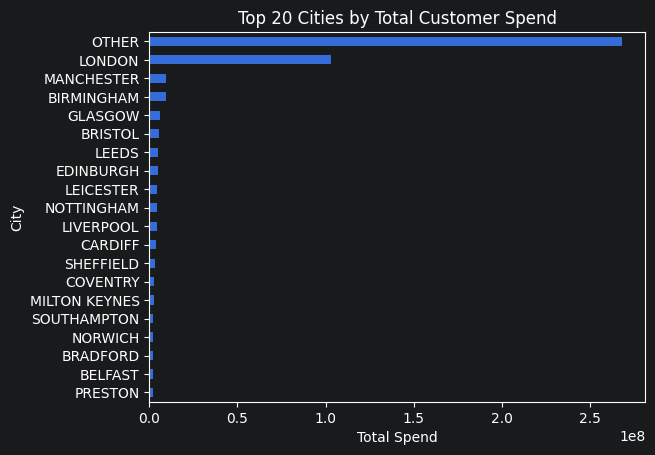

In [42]:
top_20_spend.sort_values(ascending=True).plot(kind="barh")
plt.title("Top 20 Cities by Total Customer Spend")
plt.xlabel("Total Spend")
plt.ylabel("City")
plt.show()

In [ ]:
# Compare London against the rest of the United Kingdom

In [41]:
print("Total spend for all customers:")
print(customers["total_spend"].sum())
print("Total spend for London customers:")
print(customers.loc[customers["city"] == "LONDON", "total_spend"].sum())
print("Total spend outside London:")
print(customers.loc[customers["city"] != "LONDON", "total_spend"].sum())
print("Total spend outside London (excluding OTHER):")
print(customers.loc[customers["city"].isin(["LONDON", "OTHER"]) == False,"total_spend"].sum())

Total spend for all customers:
490374100
Total spend for London customers:
103042800
Total spend outside London:
387331300
Total spend outside London (excluding OTHER):
119468400
